## pivot

The pivot function in Pandas is a method used to reshape data by transforming rows into columns. 
The Pandas pivot function comes into play when there’s a need to rearrange data from a “long” format to a “wide” format. 
Essentially, this converts certain row values into column headers, thereby giving you a broader view of your data. 
This can make the data more readable, particularly when you want to compare attributes across different entities.

Or 

Pandas provide a powerful method called pivot() to create a new DataFrame based on the 
values of an existing one by specifying columns, rows and values of interest.
A pivot typically refers to the operation of reshaping or reorganizing data.
The pivot() function allows you to:
    Set one column as the index(rows).
    Set another column as the columns of the new DataFrame.
    Set values to fill in the reshaped table.
This is particulary useful when you have categorical data that you want to convert into 
a tabular format where rows and columns represent different categories.

Syntax of pivot

    DataFrame.pivot(index = None, columns = None, values = None)

    index: Column(s) to use to make new frame’s index.
    columns: Column(s) to use to make new frame’s columns.
    values: Column(s) to populate values in the new DataFrame. If not specified, all remaining columns will be used.

#### Example1:

In [5]:
import numpy as np
import pandas as pd

In [6]:
data = {
            'Date': ['2024-01-01', '2024-01-01', '2024-01-02', '2024-01-02'],
            'City': ['New York', 'Los Angeles', 'New York', 'Los Angeles'],
            'Temperature': [30, 25, 32, 28]
        }
df = pd.DataFrame(data)
print(df)
print()
# Pivot the DataFrame
pivot_df = df.pivot(index='Date',columns='City',values='Temperature')
print(pivot_df)

         Date         City  Temperature
0  2024-01-01     New York           30
1  2024-01-01  Los Angeles           25
2  2024-01-02     New York           32
3  2024-01-02  Los Angeles           28

City        Los Angeles  New York
Date                             
2024-01-01           25        30
2024-01-02           28        32


#### Example2:

In [10]:
stocks = pd.read_csv('stocks.csv')

In [12]:
stocks

,date,symbol,open,high,low,close,volume
0,2019-03-01,AMZN,1655.13,1674.26,1651.00,1671.73,4974877
1,2019-03-04,AMZN,1685.00,1709.43,1674.36,1696.17,6167358
2,2019-03-05,AMZN,1702.95,1707.80,1689.01,1692.43,3681522
3,2019-03-06,AMZN,1695.97,1697.75,1668.28,1668.95,3996001
4,2019-03-07,AMZN,1667.37,1669.75,1620.51,1625.95,4957017
5,2019-03-01,AAPL,174.28,175.15,172.89,174.97,25886167
6,2019-03-04,AAPL,175.69,177.75,173.97,175.85,27436203
7,2019-03-05,AAPL,175.94,176.00,174.54,175.53,19737419
8,2019-03-06,AAPL,174.67,175.49,173.94,174.52,20810384
9,2019-03-07,AAPL,173.87,174.44,172.02,172.50,24796374


When we print out the code, we can see that the data has a number of columns and 
that the rows are organized by trading date and stock symbol. That organization may be helpful for some analysis, but it can be hard to glean(pick up or gather) informationabout trading volumne across dates and stock symbols. 
To do this type of analysis we have to reshape our data using pivot.

In [15]:
stocks.columns

Index(['date', 'symbol', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [17]:
#  Apply pivot method
S1 = stocks.pivot(index='symbol',columns='date')
S1

open                                                   high  \
date   2019-03-01 2019-03-04 2019-03-05 2019-03-06 2019-03-07 2019-03-01   
symbol                                                                     
AAPL       174.28     175.69     175.94     174.67     173.87     175.15   
AMZN      1655.13    1685.00    1702.95    1695.97    1667.37    1674.26   
GOOG      1124.90    1146.99    1150.06    1162.49    1155.72    1142.97   

                                                    ...      close             \
date   2019-03-04 2019-03-05 2019-03-06 2019-03-07  ... 2019-03-01 2019-03-04   
symbol                                              ...                         
AAPL       177.75     176.00     175.49     174.44  ...     174.97     175.85   
AMZN      1709.43    1707.80    1697.75    1669.75  ...    1671.73    1696.17   
GOOG      1158.28    1169.61    1167.57    1156.76  ...    1140.99    1147.80   

                                            volume                        \
date   2019-03-05 2019-03-06 2019-03-07 2019-03-01 2019-03-04 2019-03-05   
symbol                                                                     
AAPL       175.53     174.52     172.50   25886167   27436203   19737419   
AMZN      1692.43    1668.95    1625.95    4974877    6167358    3681522   
GOOG      1162.03    1157.86    1143.30    1450316    1446047    1443174   

                              
date   2019-03-06 2019-03-07  
symbol                        
AAPL     20810384   24796374  
AMZN      3996001    4957017  
GOOG      1099289    1166559  

[3 rows x 25 columns]

In [18]:
#  Apply pivot method to get date wise volumn of stock according to symbol
S2 = stocks.pivot(index='symbol',columns='date',values='volume')
S2

date,2019-03-01,2019-03-04,2019-03-05,2019-03-06,2019-03-07
symbol,,,,,
AAPL,25886167,27436203,19737419,20810384,24796374
AMZN,4974877,6167358,3681522,3996001,4957017
GOOG,1450316,1446047,1443174,1099289,1166559


In the example above, I use the pivot method to reshape the data so that the rows are indexed by stock symbol and the columns are trading dates. The value in each cell is the volume on that day. This makes it easy to compare the volume for a stock over time, by reading horizontally, or to compare volume across stocks on a particular day, by reading vertically.
This reshaping power of pivot makes it much easier to understand relationships in your datasets.

In [22]:
#  Apply pivot method to get date wise opening value of stock according to symbol
S3 = stocks.pivot(index='symbol',columns='date',values='open')
S3

date,2019-03-01,2019-03-04,2019-03-05,2019-03-06,2019-03-07
symbol,,,,,
AAPL,174.28,175.69,175.94,174.67,173.87
AMZN,1655.13,1685.00,1702.95,1695.97,1667.37
GOOG,1124.90,1146.99,1150.06,1162.49,1155.72


In [23]:
S4 = stocks.pivot(index='date',columns='symbol',values=['open','close'])
S4

open                     close                  
symbol        AAPL     AMZN     GOOG    AAPL     AMZN     GOOG
date                                                          
2019-03-01  174.28  1655.13  1124.90  174.97  1671.73  1140.99
2019-03-04  175.69  1685.00  1146.99  175.85  1696.17  1147.80
2019-03-05  175.94  1702.95  1150.06  175.53  1692.43  1162.03
2019-03-06  174.67  1695.97  1162.49  174.52  1668.95  1157.86
2019-03-07  173.87  1667.37  1155.72  172.50  1625.95  1143.30

## When  to use pivot() vs pivot_table() in pandas

There are two Pandas methods for pivoting. 
pivot ()
pivot_table()

When deciding between using the pivot or pivot_table method, you need to ask yourself
one question:
    
    Will the results of my pivot have more than one entry in any index+column?
if answer is yes then we must use the pivot_table method otherwise we use the pivot
method

Note that any use of pivot can be switched to pivot_table, but the reverse is not true. If you try to use the pivot method where there would be more than one entry in any index + column combination, it will throw a ValueError.

## pivot_table

An important part of data analysis is the process of grouping, summarizing, aggregating and calculating statistics about this data. Pandas pivot_table provide a powerful tool to perform these analysis techniques with Python

Pandas pivot_table() function is used to make a spreadsheet-style pivot table from a given DataFrame. Using a pivot table we can analyze the data very quickly and it can give more flexibility to make an excel sheet form of a given DataFrame. It can be aggregated in a numeric column as a cross-tabulation against two categorical columns.

Syntax 

df.pivot_table(values=None, index=None, columns=None, aggfunc='mean', fill_value=None, dropna=True)


index: the column to use as row labels

columns: the column that will be reshaped as columns

values: the column(s) to use for the new DataFrame's values

aggfunc: the function to use for aggregation, defaulting to 'mean'

fill_value: value to replace missing values with

dropna: whether to exclude the columns whose entries are all NaN

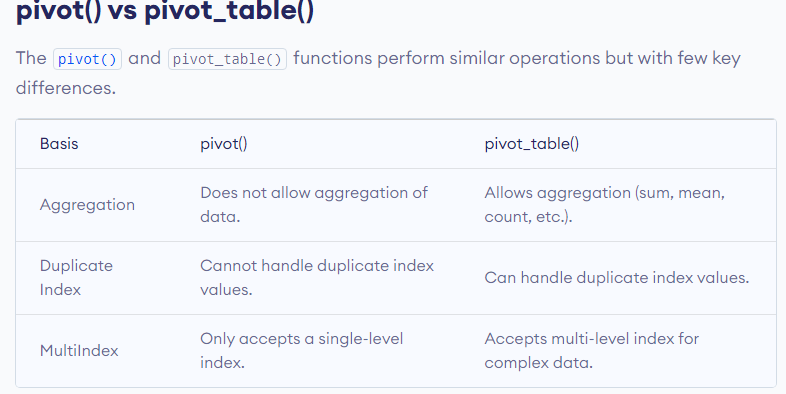

In [28]:
stocks

,date,symbol,open,high,low,close,volume
0,2019-03-01,AMZN,1655.13,1674.26,1651.00,1671.73,4974877
1,2019-03-04,AMZN,1685.00,1709.43,1674.36,1696.17,6167358
2,2019-03-05,AMZN,1702.95,1707.80,1689.01,1692.43,3681522
3,2019-03-06,AMZN,1695.97,1697.75,1668.28,1668.95,3996001
4,2019-03-07,AMZN,1667.37,1669.75,1620.51,1625.95,4957017
5,2019-03-01,AAPL,174.28,175.15,172.89,174.97,25886167
6,2019-03-04,AAPL,175.69,177.75,173.97,175.85,27436203
7,2019-03-05,AAPL,175.94,176.00,174.54,175.53,19737419
8,2019-03-06,AAPL,174.67,175.49,173.94,174.52,20810384
9,2019-03-07,AAPL,173.87,174.44,172.02,172.50,24796374


In [29]:
stocks.pivot(index='symbol',values='volume')

TypeError: pivot() missing 1 required argument: 'columns'

In [48]:
stocks.pivot_table(index='symbol',values='volume')

,volume
symbol,
AAPL,23733309.4
AMZN,4755355.0
GOOG,1321077.0


In [50]:
# OR
stocks.groupby('symbol')['volume'].mean()

symbol
AAPL    23733309.4
AMZN     4755355.0
GOOG     1321077.0
Name: volume, dtype: float64

In [52]:
stocks.pivot_table(index='symbol',values='volume',aggfunc=np.sum)

,volume
symbol,
AAPL,118666547
AMZN,23776775
GOOG,6605385


In [54]:
# OR
stocks.groupby('symbol')['volume'].sum()

symbol
AAPL    118666547
AMZN     23776775
GOOG      6605385
Name: volume, dtype: int64

### Example2:

In [57]:
df = pd.read_excel('sales-funnel.xlsx')

In [58]:
df.head()

,Account,Name,Rep,Manager,Product,Quantity,Price,Status
0,714466,Trantow-Barrows,Craig Booker,Debra Henley,CPU,1,30000,presented
1,714466,Trantow-Barrows,Craig Booker,Debra Henley,Software,1,10000,presented
2,714466,Trantow-Barrows,Craig Booker,Debra Henley,Maintenance,2,5000,pending
3,737550,"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,CPU,1,35000,declined
4,146832,Kiehn-Spinka,Daniel Hilton,Debra Henley,CPU,2,65000,won


In [59]:
df.shape

(17, 8)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Account   17 non-null     int64 
 1   Name      17 non-null     object
 2   Rep       17 non-null     object
 3   Manager   17 non-null     object
 4   Product   17 non-null     object
 5   Quantity  17 non-null     int64 
 6   Price     17 non-null     int64 
 7   Status    17 non-null     object
dtypes: int64(3), object(5)
memory usage: 1.2+ KB


As we build up the pivot table, I think it’s easiest to take it one step at a time. Add items and check each step to verify you are getting the results you expect. Don’t be afraid to play with the order and the variables to see what presentation makes the most sense for your needs.

The simplest pivot table must have a dataframe and an index . In this case, let’s use the Name as our index.

In [66]:
pd.pivot_table(df, index='Name')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2208\462634412.py:1: FutureWarning: pivot_table dropped a column because it failed to aggregate. This behavior is deprecated and will raise in a future version of pandas. Select only the columns that can be aggregated.
  pd.pivot_table(df, index='Name')


,Account,Price,Quantity
Name,,,
Barton LLC,740150,35000,1.000000
"Fritsch, Russel and Anderson",737550,35000,1.000000
Herman LLC,141962,65000,2.000000
Jerde-Hilpert,412290,5000,2.000000
"Kassulke, Ondricka and Metz",307599,7000,3.000000
Keeling LLC,688981,100000,5.000000
Kiehn-Spinka,146832,65000,2.000000
Koepp Ltd,729833,35000,2.000000
Kulas Inc,218895,25000,1.500000


You can have multiple indexes as well. In fact, most of the pivot_table args can take multiple values via a list.

In [69]:
pd.pivot_table(df,index=['Name','Rep','Manager'])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2208\3330183471.py:1: FutureWarning: pivot_table dropped a column because it failed to aggregate. This behavior is deprecated and will raise in a future version of pandas. Select only the columns that can be aggregated.
  pd.pivot_table(df,index=['Name','Rep','Manager'])


,,,Account,Price,Quantity
Name,Rep,Manager,,,
Barton LLC,John Smith,Debra Henley,740150,35000,1.000000
"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,737550,35000,1.000000
Herman LLC,Cedric Moss,Fred Anderson,141962,65000,2.000000
Jerde-Hilpert,John Smith,Debra Henley,412290,5000,2.000000
"Kassulke, Ondricka and Metz",Wendy Yule,Fred Anderson,307599,7000,3.000000
Keeling LLC,Wendy Yule,Fred Anderson,688981,100000,5.000000
Kiehn-Spinka,Daniel Hilton,Debra Henley,146832,65000,2.000000
Koepp Ltd,Wendy Yule,Fred Anderson,729833,35000,2.000000
Kulas Inc,Daniel Hilton,Debra Henley,218895,25000,1.500000


This is interesting but not particularly useful. What we probably want to do is look at this by Manager and Rep. It’s easy enough to do by changing the index .

In [72]:
pd.pivot_table(df,index=['Manager','Rep'])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2208\4202556135.py:1: FutureWarning: pivot_table dropped a column because it failed to aggregate. This behavior is deprecated and will raise in a future version of pandas. Select only the columns that can be aggregated.
  pd.pivot_table(df,index=['Manager','Rep'])


Account         Price  Quantity
Manager       Rep                                            
Debra Henley  Craig Booker   720237.0  20000.000000  1.250000
              Daniel Hilton  194874.0  38333.333333  1.666667
              John Smith     576220.0  20000.000000  1.500000
Fred Anderson Cedric Moss    196016.5  27500.000000  1.250000
              Wendy Yule     614061.5  44250.000000  3.000000

In [74]:
#  OR

df.groupby(['Manager','Rep']).mean()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2208\3181081594.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby(['Manager','Rep']).mean()


Account  Quantity         Price
Manager       Rep                                            
Debra Henley  Craig Booker   720237.0  1.250000  20000.000000
              Daniel Hilton  194874.0  1.666667  38333.333333
              John Smith     576220.0  1.500000  20000.000000
Fred Anderson Cedric Moss    196016.5  1.250000  27500.000000
              Wendy Yule     614061.5  3.000000  44250.000000

In [76]:
pd.pivot_table(df,index=['Manager','Rep'], aggfunc=np.sum)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2208\819539.py:1: FutureWarning: The operation <function sum at 0x000001E83DA827A0> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  pd.pivot_table(df,index=['Manager','Rep'], aggfunc=np.sum)


Account   Price  Quantity
Manager       Rep                                     
Debra Henley  Craig Booker   2880948   80000         5
              Daniel Hilton   584622  115000         5
              John Smith     1152440   40000         3
Fred Anderson Cedric Moss     784066  110000         5
              Wendy Yule     2456246  177000        12

In [80]:
df[df.Rep == 'Daniel Hilton']

,Account,Name,Rep,Manager,Product,Quantity,Price,Status
4,146832,Kiehn-Spinka,Daniel Hilton,Debra Henley,CPU,2,65000,won
5,218895,Kulas Inc,Daniel Hilton,Debra Henley,CPU,2,40000,pending
6,218895,Kulas Inc,Daniel Hilton,Debra Henley,Software,1,10000,presented


In [82]:
#  OR

df.groupby(['Manager','Rep']).sum()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2208\2923907669.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby(['Manager','Rep']).sum()


Account  Quantity   Price
Manager       Rep                                     
Debra Henley  Craig Booker   2880948         5   80000
              Daniel Hilton   584622         5  115000
              John Smith     1152440         3   40000
Fred Anderson Cedric Moss     784066         5  110000
              Wendy Yule     2456246        12  177000

You can see that the pivot table is smart enough to start aggregating the data and summarizing it by grouping the reps with their managers. Now we start to get a glimpse of what a pivot table can do for us.

For this purpose, the Account and Quantity columns aren’t really useful. Let’s remove it by explicitly defining the columns we care about using the values field.

In [85]:
pd.pivot_table(df,index=['Manager','Rep'], values = ['Price'])

Price
Manager       Rep                        
Debra Henley  Craig Booker   20000.000000
              Daniel Hilton  38333.333333
              John Smith     20000.000000
Fred Anderson Cedric Moss    27500.000000
              Wendy Yule     44250.000000

In [89]:
pd.pivot_table(df,index=['Manager','Rep'], values = ['Price'],aggfunc=np.mean)

Price
Manager       Rep                        
Debra Henley  Craig Booker   20000.000000
              Daniel Hilton  38333.333333
              John Smith     20000.000000
Fred Anderson Cedric Moss    27500.000000
              Wendy Yule     44250.000000

The price column automatically averages the data but we can do a count or a sum. Adding them is simple using aggfunc and np.sum .

In [87]:
pd.pivot_table(df,index=['Manager','Rep'], values = ['Price'], aggfunc=np.sum)

Price
Manager       Rep                  
Debra Henley  Craig Booker    80000
              Daniel Hilton  115000
              John Smith      40000
Fred Anderson Cedric Moss    110000
              Wendy Yule     177000

aggfunc can take a list of functions. Let’s try a mean using the numpy mean function and len to get a count.

In [91]:
pd.pivot_table(df,index=['Manager','Rep'],values = ['Price'],aggfunc=[np.mean, len])

mean   len
                                    Price Price
Manager       Rep                              
Debra Henley  Craig Booker   20000.000000     4
              Daniel Hilton  38333.333333     3
              John Smith     20000.000000     2
Fred Anderson Cedric Moss    27500.000000     4
              Wendy Yule     44250.000000     4

If we want to see sales broken down by the products, the columns variable allows us 
to define one or more columns.
Remember, columns are optional - they provide an additional way to segment the actual values 
you care about. The aggregation functions are applied to the values you list.

In [93]:
df.head()

,Account,Name,Rep,Manager,Product,Quantity,Price,Status
0,714466,Trantow-Barrows,Craig Booker,Debra Henley,CPU,1,30000,presented
1,714466,Trantow-Barrows,Craig Booker,Debra Henley,Software,1,10000,presented
2,714466,Trantow-Barrows,Craig Booker,Debra Henley,Maintenance,2,5000,pending
3,737550,"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,CPU,1,35000,declined
4,146832,Kiehn-Spinka,Daniel Hilton,Debra Henley,CPU,2,65000,won


In [95]:
pd.pivot_table(df,index=['Manager','Rep'], values = ['Price'],columns='Product', 
              aggfunc=np.sum)

Price                             
Product                           CPU Maintenance Monitor Software
Manager       Rep                                                 
Debra Henley  Craig Booker    65000.0      5000.0     NaN  10000.0
              Daniel Hilton  105000.0         NaN     NaN  10000.0
              John Smith      35000.0      5000.0     NaN      NaN
Fred Anderson Cedric Moss     95000.0      5000.0     NaN  10000.0
              Wendy Yule     165000.0      7000.0  5000.0      NaN

In [97]:
df[['Manager','Rep','Product','Price']]

,Manager,Rep,Product,Price
0,Debra Henley,Craig Booker,CPU,30000
1,Debra Henley,Craig Booker,Software,10000
2,Debra Henley,Craig Booker,Maintenance,5000
3,Debra Henley,Craig Booker,CPU,35000
4,Debra Henley,Daniel Hilton,CPU,65000
5,Debra Henley,Daniel Hilton,CPU,40000
6,Debra Henley,Daniel Hilton,Software,10000
7,Debra Henley,John Smith,Maintenance,5000
8,Debra Henley,John Smith,CPU,35000
9,Fred Anderson,Cedric Moss,CPU,65000


In [99]:
#  The NaN’s are a bit distracting. If we want to remove them, we could use fill_value to set them to 0.
pd.pivot_table(df,index=['Manager','Rep'], values = ['Price'],columns='Product', 
              aggfunc=np.sum,fill_value=0)

Price                             
Product                         CPU Maintenance Monitor Software
Manager       Rep                                               
Debra Henley  Craig Booker    65000        5000       0    10000
              Daniel Hilton  105000           0       0    10000
              John Smith      35000        5000       0        0
Fred Anderson Cedric Moss     95000        5000       0    10000
              Wendy Yule     165000        7000    5000        0

In [101]:
# I think it would be useful to add the quantity as well. Add Quantity to the values list.
pd.pivot_table(df,index=['Manager','Rep'], values = ['Price','Quantity'],columns=['Product'], 
              aggfunc=np.sum,fill_value=0)

Price                              Quantity  \
Product                         CPU Maintenance Monitor Software      CPU   
Manager       Rep                                                           
Debra Henley  Craig Booker    65000        5000       0    10000        2   
              Daniel Hilton  105000           0       0    10000        4   
              John Smith      35000        5000       0        0        1   
Fred Anderson Cedric Moss     95000        5000       0    10000        3   
              Wendy Yule     165000        7000    5000        0        7   

                                                          
Product                     Maintenance Monitor Software  
Manager       Rep                                         
Debra Henley  Craig Booker            2       0        1  
              Daniel Hilton           0       0        1  
              John Smith              2       0        0  
Fred Anderson Cedric Moss             1       0        1  
              Wendy Yule              3       2        0

In [103]:
pd.pivot_table(df,index=['Manager','Rep','Product'], values = ['Price','Quantity']
              ,aggfunc=np.sum, fill_value=0)

Price  Quantity
Manager       Rep           Product                      
Debra Henley  Craig Booker  CPU           65000         2
                            Maintenance    5000         2
                            Software      10000         1
              Daniel Hilton CPU          105000         4
                            Software      10000         1
              John Smith    CPU           35000         1
                            Maintenance    5000         2
Fred Anderson Cedric Moss   CPU           95000         3
                            Maintenance    5000         1
                            Software      10000         1
              Wendy Yule    CPU          165000         7
                            Maintenance    7000         3
                            Monitor        5000         2

In [105]:
pd.pivot_table(df,index=['Manager','Rep','Product'], values = ['Price','Quantity']
              ,aggfunc=[np.sum,np.mean], fill_value=0)

sum            mean         
                                          Price Quantity  Price Quantity
Manager       Rep           Product                                     
Debra Henley  Craig Booker  CPU           65000        2  32500      1.0
                            Maintenance    5000        2   5000      2.0
                            Software      10000        1  10000      1.0
              Daniel Hilton CPU          105000        4  52500      2.0
                            Software      10000        1  10000      1.0
              John Smith    CPU           35000        1  35000      1.0
                            Maintenance    5000        2   5000      2.0
Fred Anderson Cedric Moss   CPU           95000        3  47500      1.5
                            Maintenance    5000        1   5000      1.0
                            Software      10000        1  10000      1.0
              Wendy Yule    CPU          165000        7  82500      3.5
                            Maintenance    7000        3   7000      3.0
                            Monitor        5000        2   5000      2.0

For this data set, this representation makes more sense. Now, what if I want to see some totals? margins=True does that for us.

In [108]:
pd.pivot_table(df,index=['Manager','Rep','Product'], values = ['Price','Quantity']
              ,aggfunc=[np.sum,np.mean], fill_value=0,margins=True)

sum                   mean  \
                                          Price Quantity         Price   
Manager       Rep           Product                                      
Debra Henley  Craig Booker  CPU           65000        2  32500.000000   
                            Maintenance    5000        2   5000.000000   
                            Software      10000        1  10000.000000   
              Daniel Hilton CPU          105000        4  52500.000000   
                            Software      10000        1  10000.000000   
              John Smith    CPU           35000        1  35000.000000   
                            Maintenance    5000        2   5000.000000   
Fred Anderson Cedric Moss   CPU           95000        3  47500.000000   
                            Maintenance    5000        1   5000.000000   
                            Software      10000        1  10000.000000   
              Wendy Yule    CPU          165000        7  82500.000000   
                            Maintenance    7000        3   7000.000000   
                            Monitor        5000        2   5000.000000   
All                                      522000       30  30705.882353   

                                                   
                                         Quantity  
Manager       Rep           Product                
Debra Henley  Craig Booker  CPU          1.000000  
                            Maintenance  2.000000  
                            Software     1.000000  
              Daniel Hilton CPU          2.000000  
                            Software     1.000000  
              John Smith    CPU          1.000000  
                            Maintenance  2.000000  
Fred Anderson Cedric Moss   CPU          1.500000  
                            Maintenance  1.000000  
                            Software     1.000000  
              Wendy Yule    CPU          3.500000  
                            Maintenance  3.000000  
                            Monitor      2.000000  
All                                      1.764706

Let’s move the analysis up a level and look at our pipeline at the manager level. Notice how the status is ordered based on our earlier category definition.

In [ ]:
pd.pivot_table(df,index=['Manager','Status'],values = 'Price',
              aggfunc=np.sum, fill_value=0, margins=True)

A really handy feature is the ability to pass a dictionary to the aggfunc so you can perform different functions on each of the values you select. This has a side-effect of making the labels a little cleaner.

In [ ]:
df.pivot_table(index=['Manager','Status'],columns='Product',
               values = ['Price','Quantity'],aggfunc={'Quantity':len, 'Price':np.sum},
               fill_value=0)

You can provide a list of aggfunctions to apply to each value too:

In [41]:
table = pd.pivot_table(df,index=["Manager","Status"],columns=["Product"],values=["Quantity","Price"],
               aggfunc={"Quantity":len,"Price":[np.sum,np.mean]},fill_value=0)
table

KeyError: 'Quantity'

### Advanced Pivot Table Filtering
Once you have generated your data, it is in a DataFrame so you can filter on it using your normal DataFrame functions.

In [ ]:
table.query('Manager==["Debra Henley"]')

In [ ]:
table.query('Status==["pending","won"]')

#### Example:-

In [ ]:
df1 = pd.read_excel('October_Status.xlsx',skipfooter=1)

In [ ]:
df1.shape

In [ ]:
col = ['Sno','District','Local_Body','Depor','FPS_ID','Total_Cards','FPS_Status']

In [ ]:
df1

In [23]:
df1 = df1[2:]

In [25]:
df1

,FPS details for October'2024,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
2,1,Agar,"Janpad Panchayat, AGAR",Agar,1905003,385,Online
3,2,Agar,"Janpad Panchayat, AGAR",Agar,1905004,480,Online
4,3,Agar,"Janpad Panchayat, AGAR",Agar,1905005,267,Online
5,4,Agar,"Janpad Panchayat, AGAR",Agar,1905006,363,Online
6,5,Agar,"Janpad Panchayat, AGAR",Agar,1905007,681,Online
...,...,...,...,...,...,...,...
27900,27899,Vidisha,"Nagar Praishad, Kurwai",Kurwai,2705052,515,Online
27901,27900,Vidisha,"Nagar Praishad, Kurwai",Kurwai,2705053,629,Online
27902,27901,Vidisha,"Nagar Praishad, Kurwai",Kurwai,2705060,730,Online
27903,27902,Vidisha,"Nagar Praishad, Lateri",Lateri,2707038,1355,Online


In [31]:
df1.columns = col

In [35]:
df1.head()

,Sno,District,Local_Body,Depor,FPS_ID,Total_Cards,FPS_Status
2,1,Agar,"Janpad Panchayat, AGAR",Agar,1905003,385,Online
3,2,Agar,"Janpad Panchayat, AGAR",Agar,1905004,480,Online
4,3,Agar,"Janpad Panchayat, AGAR",Agar,1905005,267,Online
5,4,Agar,"Janpad Panchayat, AGAR",Agar,1905006,363,Online
6,5,Agar,"Janpad Panchayat, AGAR",Agar,1905007,681,Online


In [39]:
df1.shape

(27903, 7)

In [41]:
df1.set_index('Sno',inplace=True)

In [45]:
df1.head()

,District,Local_Body,Depor,FPS_ID,Total_Cards,FPS_Status
Sno,,,,,,
1,Agar,"Janpad Panchayat, AGAR",Agar,1905003,385,Online
2,Agar,"Janpad Panchayat, AGAR",Agar,1905004,480,Online
3,Agar,"Janpad Panchayat, AGAR",Agar,1905005,267,Online
4,Agar,"Janpad Panchayat, AGAR",Agar,1905006,363,Online
5,Agar,"Janpad Panchayat, AGAR",Agar,1905007,681,Online


In [61]:
pd.pivot_table(df1, index=['District','Local_Body'],columns=['FPS_Status'], values='FPS_ID', aggfunc=np.size, fill_value=0, margins=True)

FPS_Status                           Offline  Online  Poffline    All
District Local_Body                                                  
Agar     Janpad Panchayat, AGAR            0      61         1     62
         Janpad Panchayat, BAROD           0      70         0     70
         Janpad Panchayat, NALKHEDA        0      48         0     48
         Janpad Panchayat, SUSNER          0      64         0     64
         Nagar Palika, AGAR                0       9         0      9
...                                      ...     ...       ...    ...
Vidisha  Nagar Palika, Vidisha             0      39         0     39
         Nagar Parishad, Shamshabad        0       2         0      2
         Nagar Praishad, Kurwai            0       4         0      4
         Nagar Praishad, Lateri            0       2         0      2
All                                       44   27166       693  27903

[745 rows x 4 columns]

In [71]:
pd.pivot_table(df1, index=['District'],columns=['FPS_Status'], values='FPS_ID', aggfunc=np.size, fill_value=0, margins=True)

FPS_Status,Offline,Online,Poffline,All
District,,,,
Agar,0,270,1,271
Alirajpur,0,280,18,298
Anuppur,0,297,8,305
Ashoknagar,0,344,0,344
Balaghat,2,706,54,762
Barwani,0,434,56,490
Betul,0,604,56,660
Bhind,0,575,0,575
Bhopal,0,503,0,503
